<center><span style="font-size:50px;"><b>INITIAL ANALYSIS</b></span></center>

---

---

---

---

<center><span style="font-size:30px;"><b>UPLOADING DATA</b></span></center>

In [3]:
import pandas as pd
df = pd.read_csv("data/USGS/us_earthquakes_1985_2025.csv")

Let's observe the obtained dataframe:

In [5]:
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns):_} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([df.head(3),df.tail(3)]) )

The uploaded dataframe has 689_547 rows and 6 columns.
It occupies 121.98 MB in RAM memory


,time,magnitude,place,longitude,latitude,depth_km
0,1985-01-01T00:47:31.230000,1.57,"24 km ENE of Greenfield, California",-121.013167,36.437167,5.6000
1,1985-01-01T00:53:22.800000,1.72,"13km N of Cabazon, CA",-116.796000,34.033000,11.9540
2,1985-01-01T02:49:27.190000,1.56,"6 km W of Cobb, California",-122.796000,38.830500,0.5260
689544,2025-12-31T22:40:27.580000,2.08,"14 km NNW of Susanville, CA",-120.691833,40.540500,3.2700
689545,2025-12-31T23:24:31.670000,2.74,"46 km WSW of Ferndale, CA",-124.793167,40.489833,22.3100
689546,2025-12-31T23:27:57.835000,2.20,"49 km NW of Toyah, Texas",-104.135000,31.653000,5.5231


In [6]:
print("\nCOLUMNS:")
print(df.columns)


COLUMNS:
Index(['time', 'magnitude', 'place', 'longitude', 'latitude', 'depth_km'], dtype='str')


Meaning of the less obvious comlumns (the majority are useless to us):
* depth: Depth of the earthquake in kilometers (km).
* mag: Magnitude of the earthquake
* magType: Type of magnitude used. (maybe we should confront only earthquake with same magtype?)
* nst: Number of seismic stations that reported the event.
* gap: Largest azimuthal gap in station coverage (degrees).
* dmin: Distance to the nearest station (in degrees).
* rms: Root mean square of the travel time residuals (in seconds).
* net: Network that detected the event (e.g., us, ci, hv). It identifies the organization or seismic network responsible.
* id: The unique identifier for the earthquake event. It’s usually a string combining the net code and a unique event code.
* updated: Time the event information was last updated.
* place: Human-readable location (e.g., "10km SE of Town X").
* type: Type of seismic event (earthquake, quarry blast, etc.). But I only downloaded earthquakes so this column should be useless.
* horizontalError: Horizontal location error (in km or m).
* depthError: Error estimate for the depth (in km).
* magError: Error estimate for the magnitude.
* magNst: Number of stations used for magnitude calculation.
* status: Review status of the event (reviewed, automatic). It means whether the data has been automatically generated or manually reviewed by a seismologist.
* locationSource: Agency that determined the location.
* magSource: Agency that determined the magnitude.

---

---

---

---

<center><span style="font-size:30px;"><b>FILTERING DATA</b></span></center>

Let's keep only earthquakes happened in Italy and only useful columns:

In [1]:
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns):_} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")

display( pd.concat([df.head(5),df.tail(5)]) )

NameError: name 'df' is not defined

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots in the notebook
sns.set_theme(style="whitegrid")
%matplotlib inline

# Assuming your dataframe is named 'df'
# Convert the 'time' column to datetime format (handles various formats automatically)
df['time'] = pd.to_datetime(df['time'], utc=True)

# Create a new 'year' column for our grouped analyses
df['year'] = df['time'].dt.year

# Take a quick look to ensure everything is correct
display(df.tail())

,time,magnitude,place,longitude,latitude,depth_km,year
689542,2025-12-31 21:04:12.780000+00:00,1.73,"31 km S of Mammoth, Wyoming",-110.691167,44.691000,7.0500,2025
689543,2025-12-31 22:21:52.891000+00:00,1.70,"20 km NW of Stanton, Texas",-101.930000,32.272000,6.8848,2025
689544,2025-12-31 22:40:27.580000+00:00,2.08,"14 km NNW of Susanville, CA",-120.691833,40.540500,3.2700,2025
689545,2025-12-31 23:24:31.670000+00:00,2.74,"46 km WSW of Ferndale, CA",-124.793167,40.489833,22.3100,2025
689546,2025-12-31 23:27:57.835000+00:00,2.20,"49 km NW of Toyah, Texas",-104.135000,31.653000,5.5231,2025


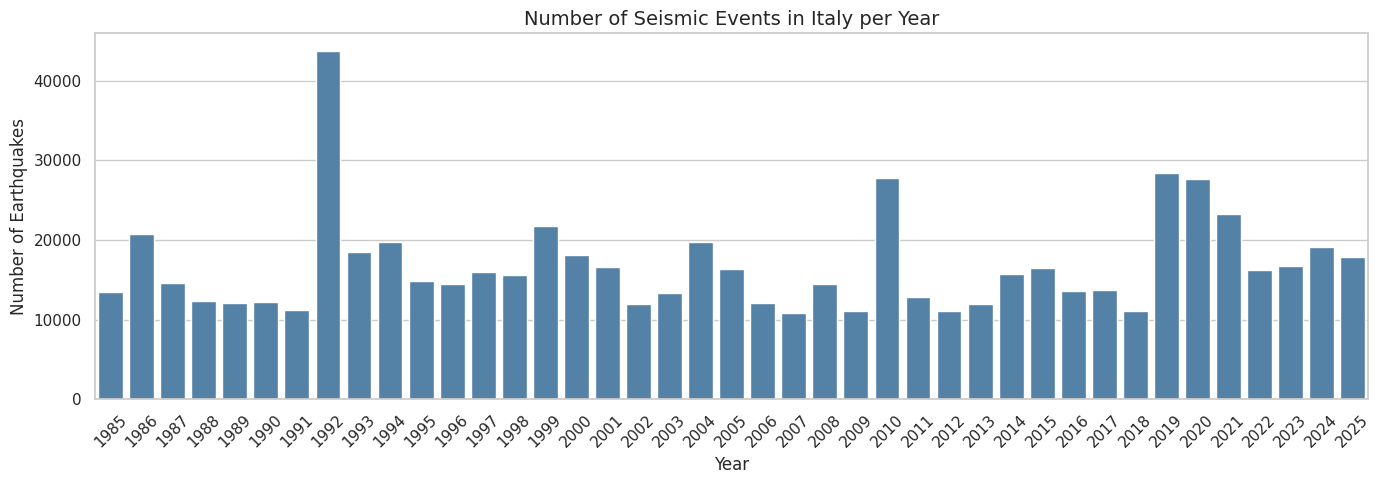

In [8]:
plt.figure(figsize=(14, 5))
sns.countplot(data=df, x='year', color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of Seismic Events in Italy per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.tight_layout()
plt.show()

/tmp/ipykernel_230083/2734497454.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='magnitude', palette='viridis')


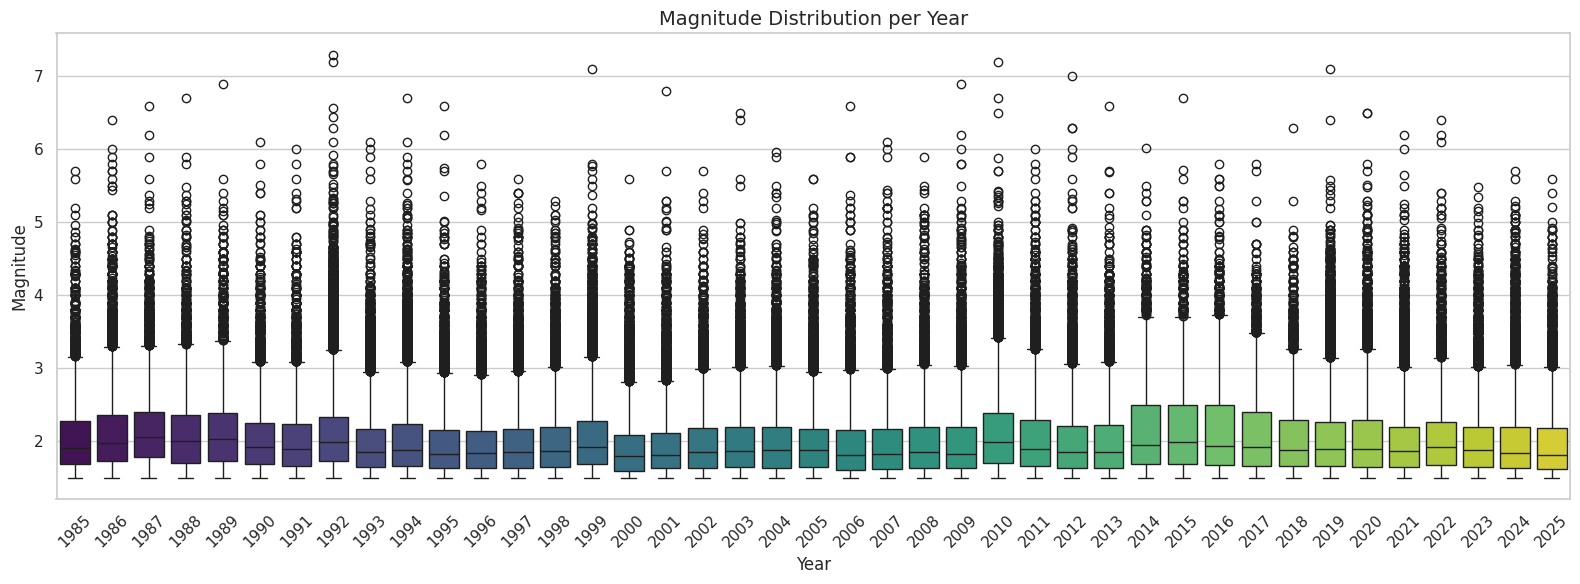

In [10]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x='year', y='magnitude', palette='viridis')
plt.xticks(rotation=45)
plt.title('Magnitude Distribution per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

/tmp/ipykernel_230083/737046956.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='depth_km', palette='magma')


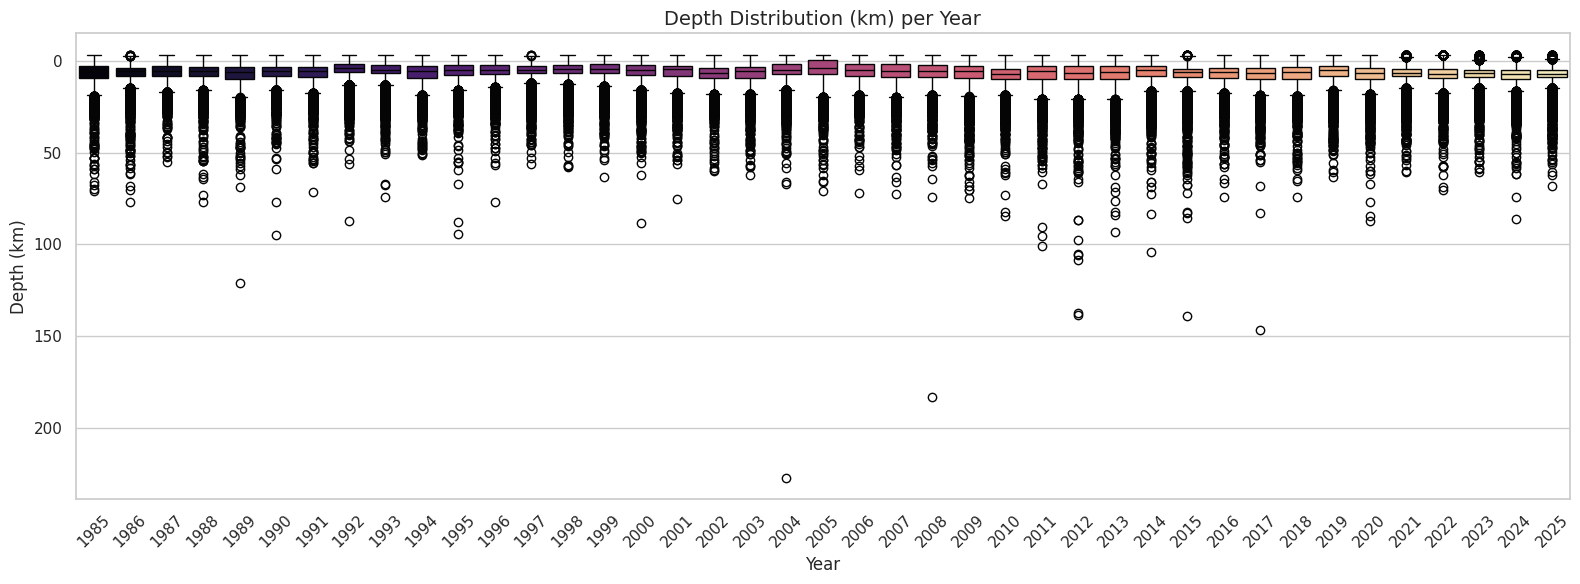

In [11]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=df, x='year', y='depth_km', palette='magma')

# Invert the Y-axis to visually simulate underground depth (0 at the top)
plt.gca().invert_yaxis() 

plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

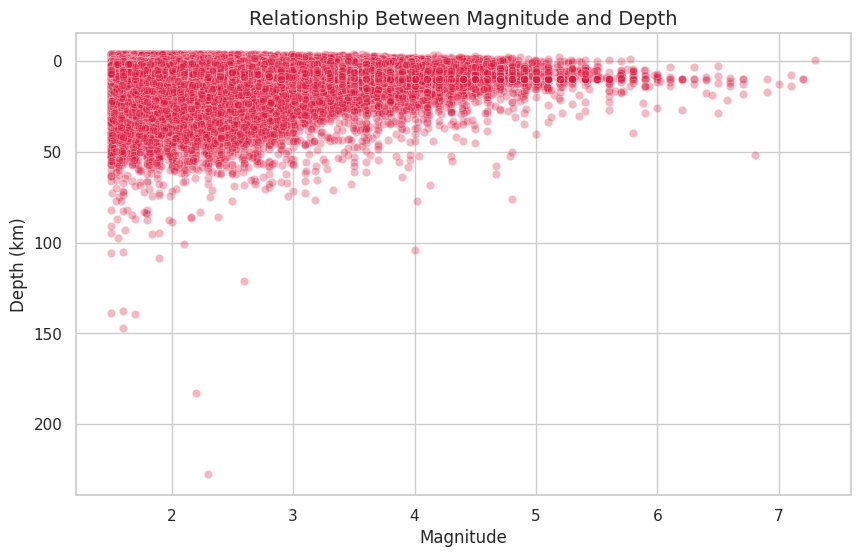

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='magnitude', y='depth_km', alpha=0.3, color='crimson')

# Invert the Y-axis here as well for consistency
plt.gca().invert_yaxis()

plt.title('Relationship Between Magnitude and Depth', fontsize=14)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()